In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

# CIFAR-10 Datasets with Augmentation
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=train_transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=test_transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
classes = train_dataset.classes

100%|██████████| 170M/170M [00:03<00:00, 49.5MB/s]


In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16x16

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 8x8
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(15):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Accuracy={acc:.2f}%")
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"\n Test Accuracy : {test_acc:.2f}%")

Epoch 1: Loss=686.0698, Accuracy=36.10%
Epoch 2: Loss=559.0733, Accuracy=47.91%
Epoch 3: Loss=510.7889, Accuracy=52.44%
Epoch 4: Loss=478.9789, Accuracy=55.67%
Epoch 5: Loss=461.4073, Accuracy=57.39%
Epoch 6: Loss=445.9698, Accuracy=59.23%
Epoch 7: Loss=432.1676, Accuracy=60.59%
Epoch 8: Loss=420.5890, Accuracy=61.85%
Epoch 9: Loss=407.0054, Accuracy=63.16%
Epoch 10: Loss=399.2706, Accuracy=63.69%
Epoch 11: Loss=391.6243, Accuracy=64.60%
Epoch 12: Loss=382.5756, Accuracy=65.47%
Epoch 13: Loss=374.5671, Accuracy=66.02%
Epoch 14: Loss=368.3569, Accuracy=66.93%
Epoch 15: Loss=362.5842, Accuracy=67.36%

 Test Accuracy : 75.18%


In [ ]:
def show_augmented_versions(single_image_tensor, transform_pipeline, n=10):
    rows, cols = 2, n // 2
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.5))
    fig.suptitle("Augmented Versions", fontsize=14)

    for i in range(n):
        augmented_img = transform_pipeline(single_image_tensor)
        img_np = augmented_img.permute(1, 2, 0).numpy()
        ax = axes[i // cols, i % cols]
        ax.imshow(img_np)
        ax.axis('off')

    plt.tight_layout()
    plt.show()



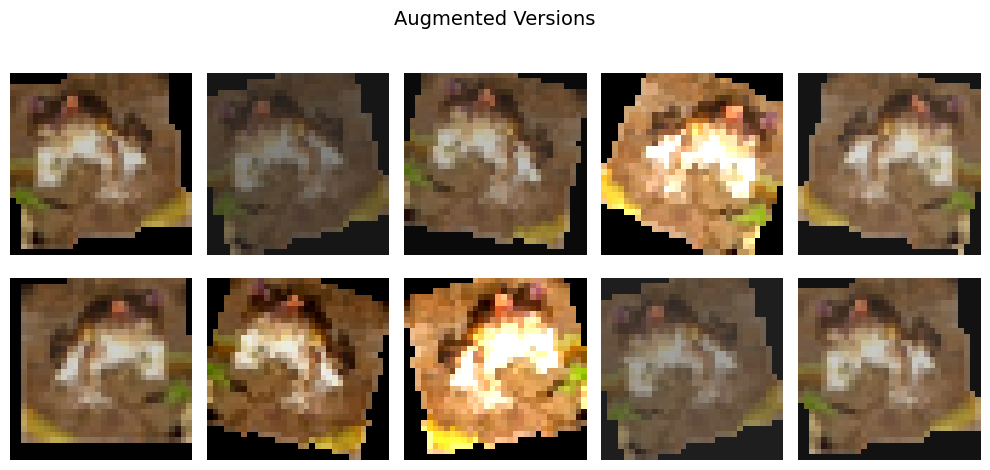

In [ ]:
# sample_img is already a tensor
sample_img, _ = train_dataset[0]  # Tensor

# Define transform without ToTensor
transform_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    # No ToTensor()
])

show_augmented_versions(sample_img, transform_pipeline, n=10)
